In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dir = "intel-image-classification/seg_train/seg_train"
test_dir = "intel-image-classification/seg_test/seg_test"

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

/Users/anzarhussain/Documents/Deep Learning Tensorflow/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 346M/346M [01:03<00:00, 5.71MB/s] 

Extracting files...


Path to dataset files: /Users/anzarhussain/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


In [4]:
import os

print(os.listdir(path))

['seg_test', 'seg_train', 'seg_pred']


In [5]:
print(os.listdir(os.path.join(path, "seg_train")))

['seg_train']


In [6]:
train_dir = os.path.join(
    path,
    "seg_train",
    "seg_train"
)

test_dir = os.path.join(
    path,
    "seg_test",
    "seg_test"
)

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [12]:
class_names = train_ds.class_names

print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


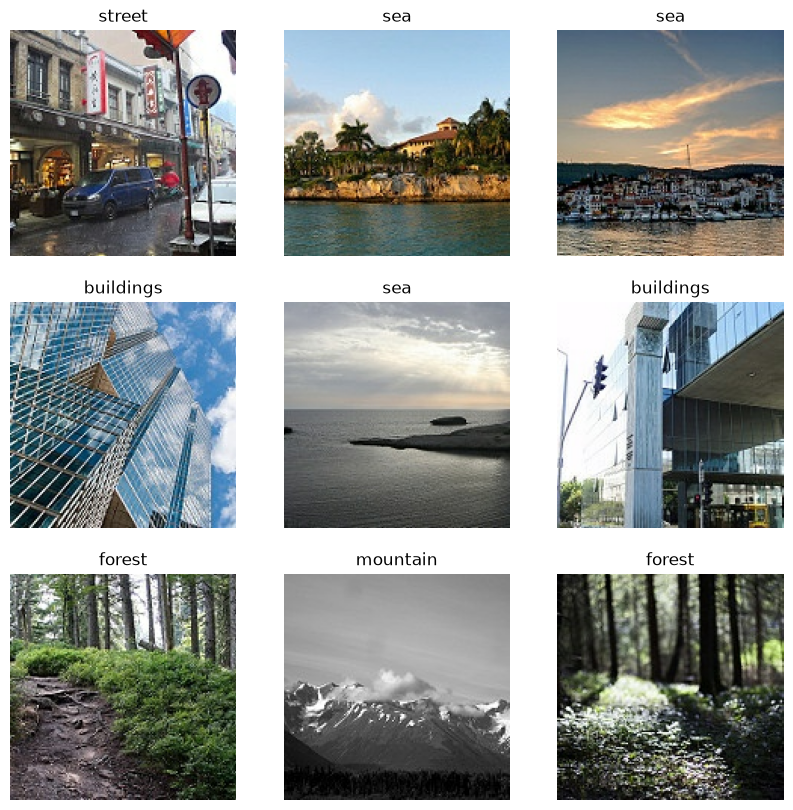

In [16]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [17]:
model = tf.keras.Sequential([

    # Input + normalization
    tf.keras.layers.Input(shape=(150, 150, 3)),
    tf.keras.layers.Rescaling(1./255),

    # Convolution Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps → vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Output layer
    tf.keras.layers.Dense(
        6,
        activation="softmax"
    )
])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15
)

Epoch 1/15


/Users/anzarhussain/Documents/Deep Learning Tensorflow/myenv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


439/439 ━━━━━━━━━━━━━━━━━━━━ 69s 156ms/step - accuracy: 0.6548 - loss: 0.9072 - val_accuracy: 0.7047 - val_loss: 0.8237
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.7931 - loss: 0.5789 - val_accuracy: 0.8157 - val_loss: 0.5206
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 109s 248ms/step - accuracy: 0.8373 - loss: 0.4531 - val_accuracy: 0.8093 - val_loss: 0.5191
Epoch 4/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 96s 219ms/step - accuracy: 0.8803 - loss: 0.3339 - val_accuracy: 0.8100 - val_loss: 0.5800
Epoch 5/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 99s 225ms/step - accuracy: 0.9139 - loss: 0.2441 - val_accuracy: 0.8200 - val_loss: 0.6254
Epoch 6/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 104s 236ms/step - accuracy: 0.9435 - loss: 0.1628 - val_accuracy: 0.8087 - val_loss: 0.7834
Epoch 7/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 109s 249ms/step - accuracy: 0.9586 - loss: 0.1210 - val_accuracy: 0.7947 - val_loss: 0.9781
Epoch 8/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 118s 270ms/step - accuracy: 0.9699 - loss: 0.0913 -

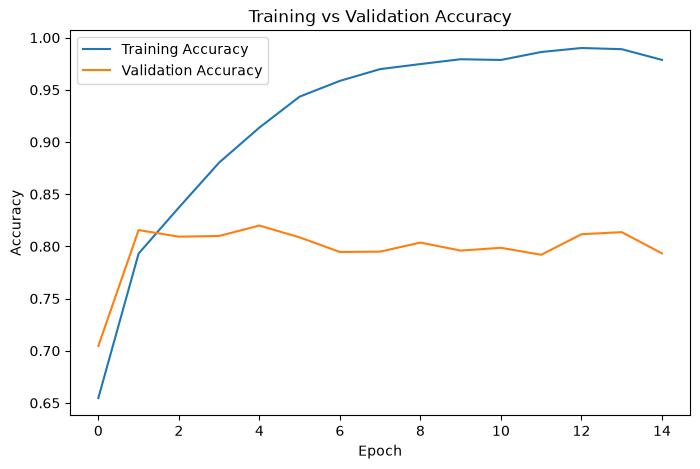

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

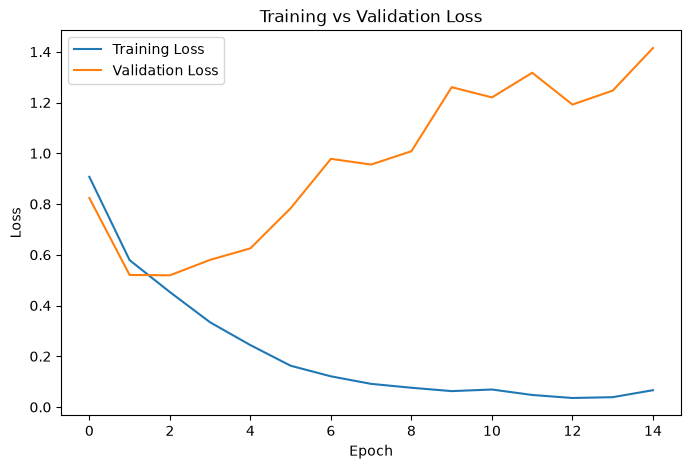

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [23]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.7933 - loss: 1.4149
Test Loss: 1.4148640632629395
Test Accuracy: 0.7933333516120911


In [24]:
images, labels = next(iter(test_ds))

predictions = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


In [1]:
predicted_classes = np.argmax(
    predictions,
    axis=1
)

NameError: name 'np' is not defined

NameError: name 'predicted_classes' is not defined

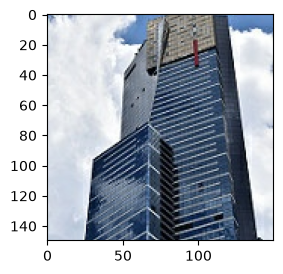

In [25]:
plt.figure(figsize=(12, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        images[i].numpy().astype("uint8")
    )

    predicted = class_names[predicted_classes[i]]
    actual = class_names[labels[i]]

    plt.title(
        f"Predicted: {predicted}\nActual: {actual}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("intel_scene_cnn.keras")

In [ ]:
model = tf.keras.models.load_model(
    "intel_scene_cnn.keras"
)

## introduce data augmentation and Dropout.

In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)

])

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(150, 150, 3)
    ),

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32, (3, 3), activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64, (3, 3), activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128, (3, 3), activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        256, (3, 3), activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        6,
        activation="softmax"
    )
])